In [1]:
%load_ext autoreload
%autoreload 3
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, warnings
import numpy as np

sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/')
from config import SPE1_PICKLE_ROOT
from pop_ridge_utils import (
    load_population_results, aggregate_population,
    run_population_tests, plot_population_results,
    build_population_scatter, save_population_results,
)
from ridge_regression_utils import FEAT_LABELS

warnings.filterwarnings('ignore')

In [2]:
# ── Configuration ─────────────────────────────────────────────────────────────
RIDGE_PICKLE_DIR = SPE1_PICKLE_ROOT + '/ridge_regression_pickles'
PRE_WIN          = (-0.055, -0.005)
POST_WIN         = ( 0.005,  0.055)
BASELINE_WIN     = (-0.20,  -0.10)
FDR_Q            = 0.05
MIN_CELLS        = 5

In [3]:
# ── Load all cell pickles ──────────────────────────────────────────────────────
all_results, cell_ids, target_names, predictor_sets = load_population_results(RIDGE_PICKLE_DIR)

feat_labels   = FEAT_LABELS
target_labels = (
    [f'Pre {l}'     for l in feat_labels] +
    [f'Pre−BL {l}'  for l in feat_labels] +
    [f'Post {l}'    for l in feat_labels] +
    [f'Post−BL {l}' for l in feat_labels] +
    [f'Δ {l}'       for l in feat_labels]
)

print(f'Loaded {len(all_results)} cells  |  {len(target_names)} targets')

Loaded 37 cells  |  25 targets  |  3 predictor sets
Loaded 37 cells  |  25 targets


In [4]:
# ── 2. Aggregate R², significance, and betas across cells ──────────────────────
r2_pop, sig_pop, beta_pop = aggregate_population(
    all_results, cell_ids, target_names, predictor_sets)

In [5]:
# ── 3. Population t-tests + FDR correction ────────────────────────────────────
df_tests = run_population_tests(
    beta_pop, target_names, target_labels,
    min_cells=MIN_CELLS, fdr_q=FDR_Q,
)

Population tests: 200 total  |  raw p<0.05: 15  |  FDR q<0.05: 0


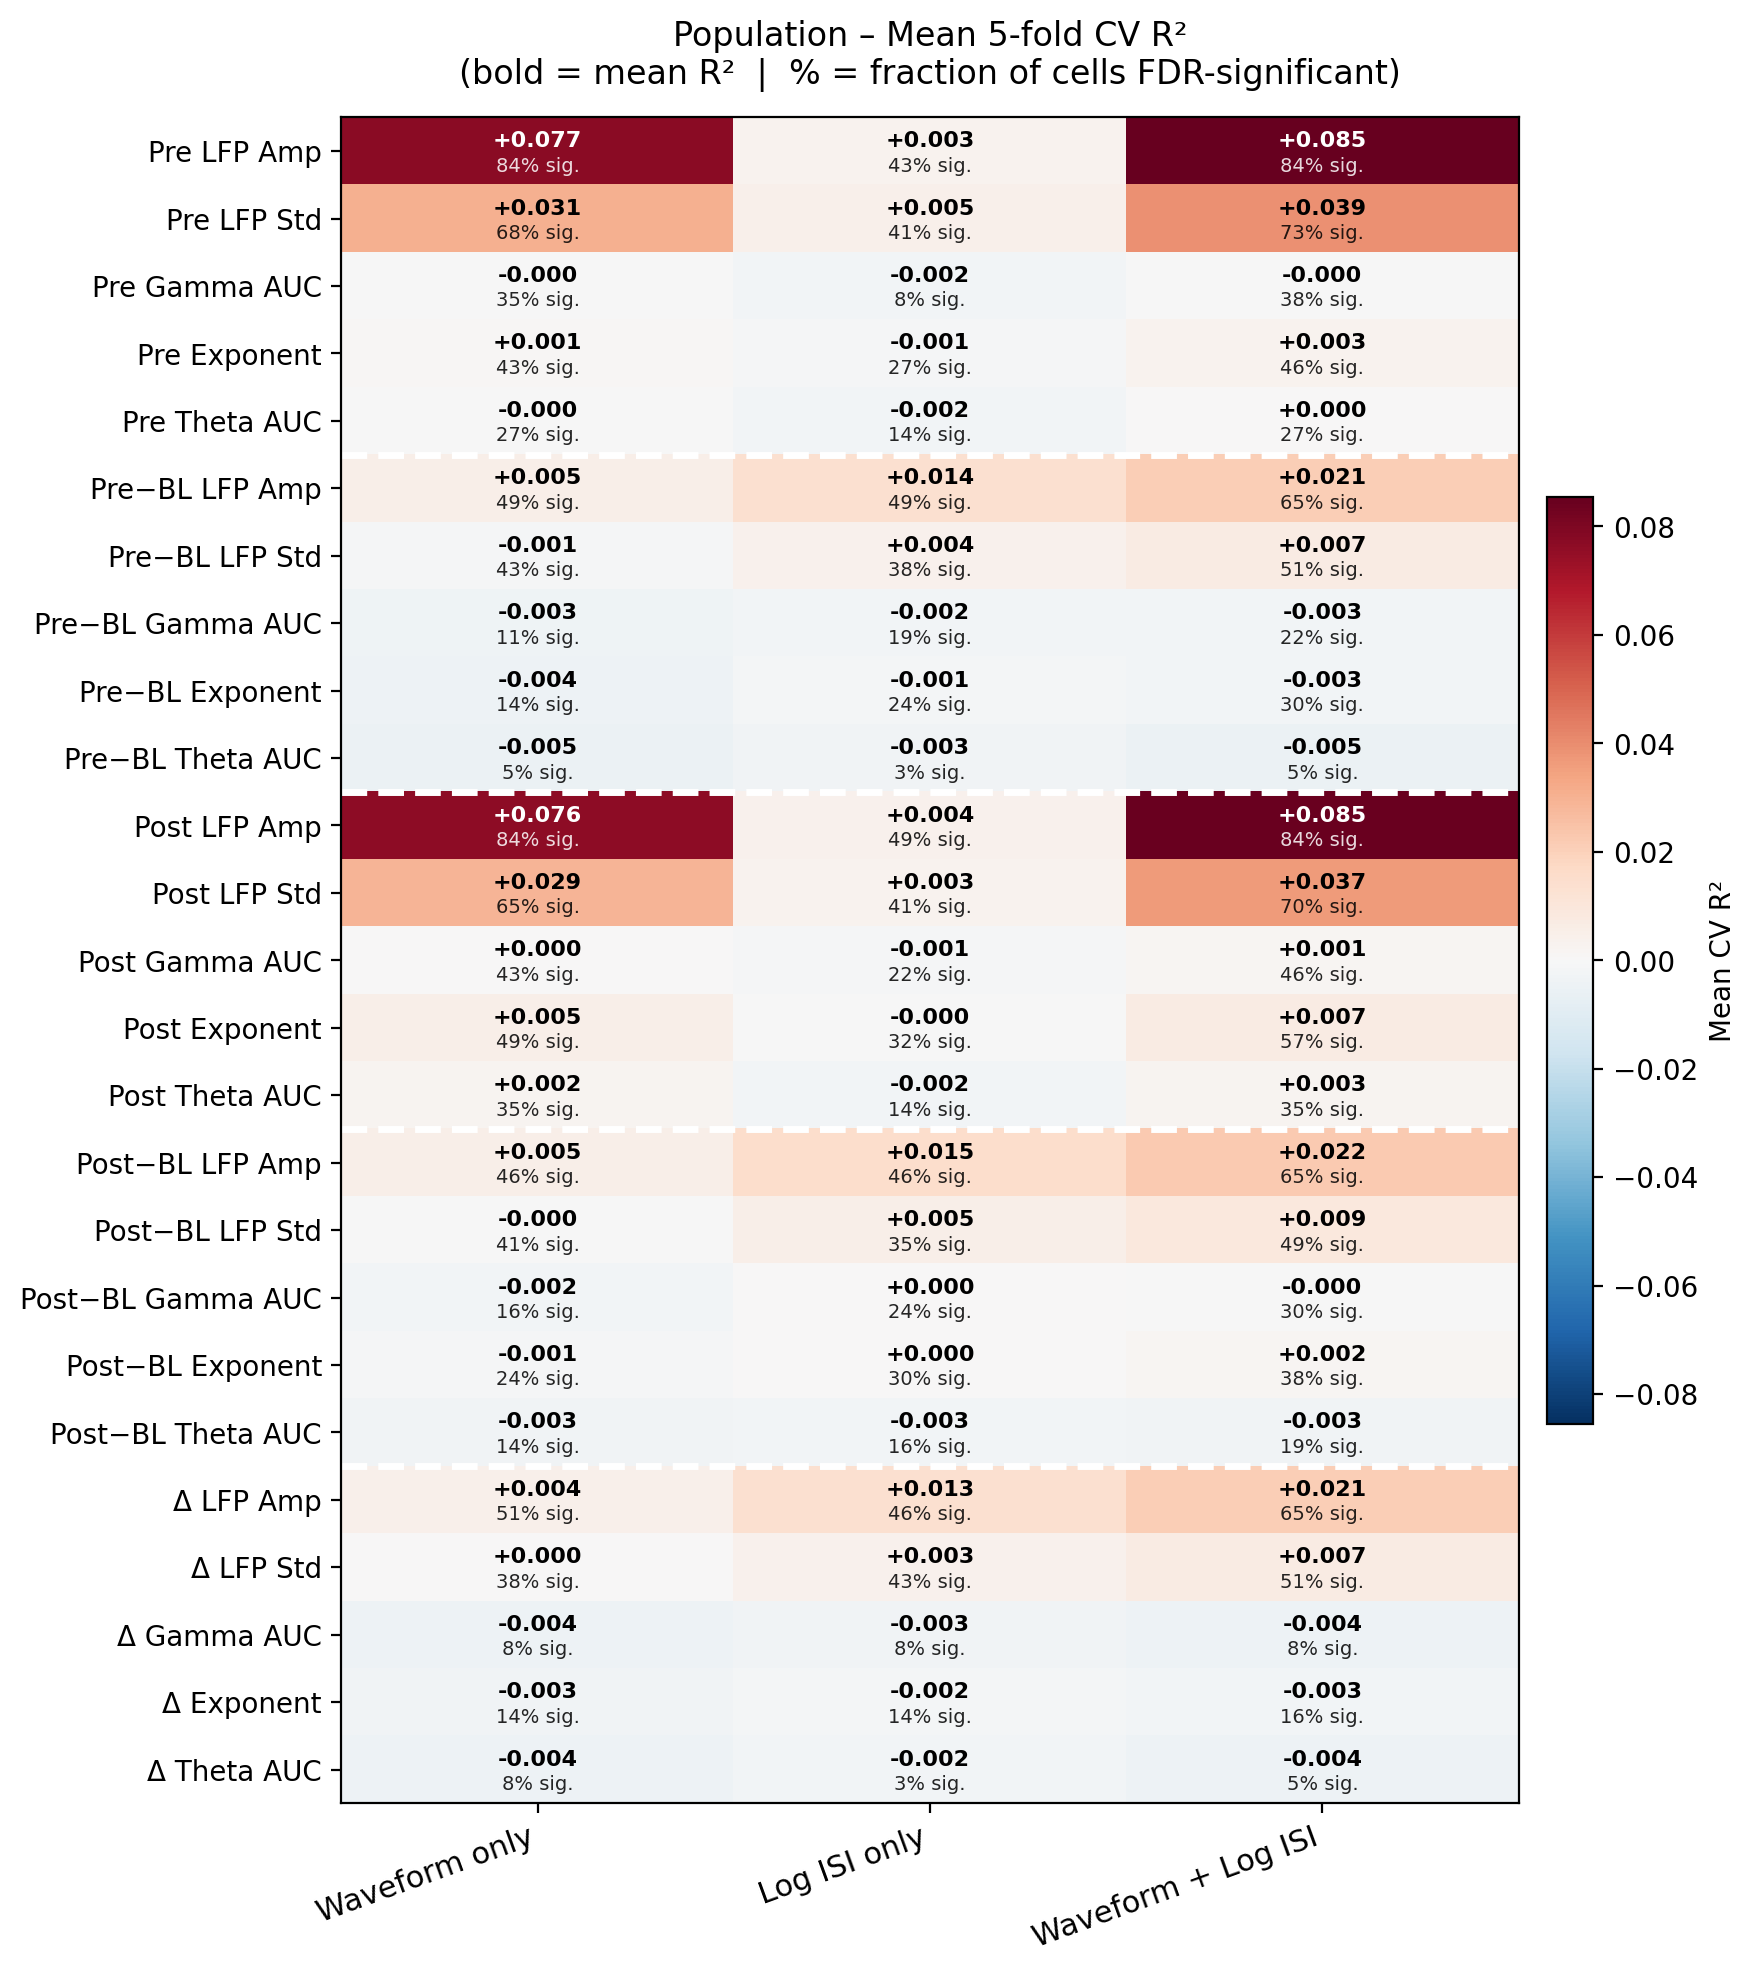

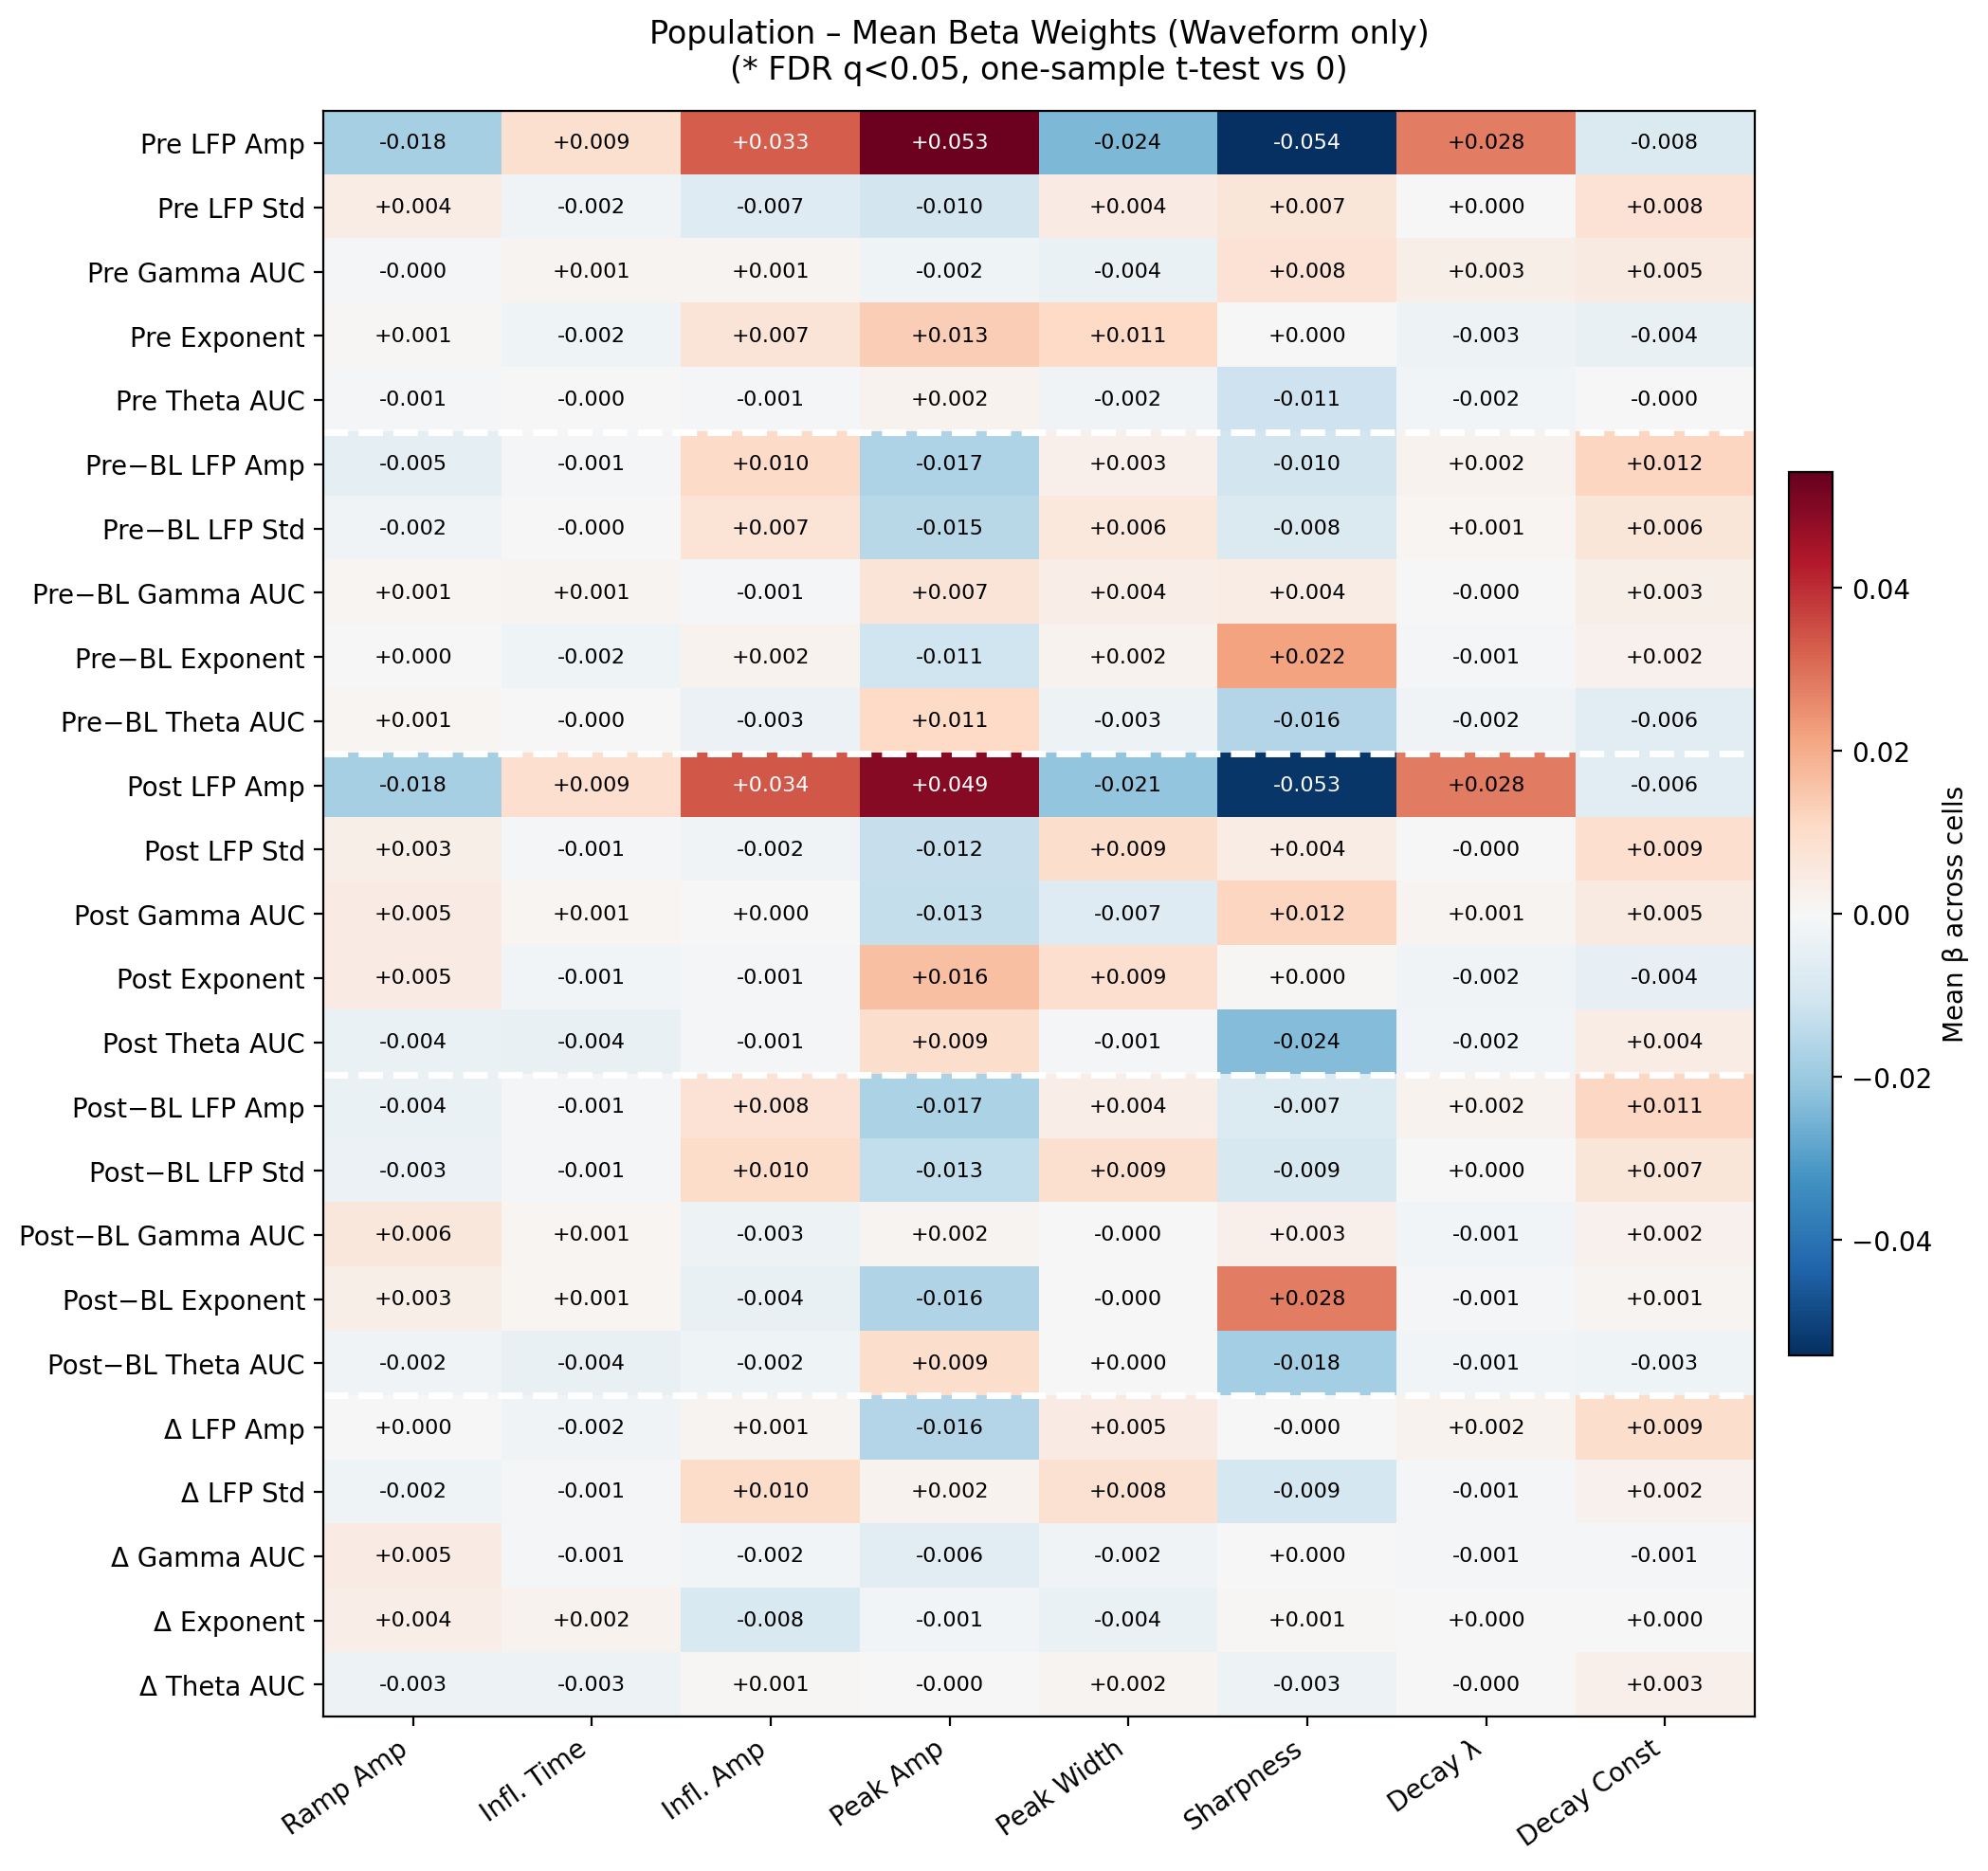

No population-level FDR-significant pairs.


In [6]:
# ── 4. Plots: R² heatmap, beta heatmap, rainclouds ────────────────────────────
mean_r2, frac_sig, mean_beta_mat, sig_beta_mat = plot_population_results(
    r2_pop, sig_pop, beta_pop, df_tests,
    target_names, target_labels, predictor_sets,
)

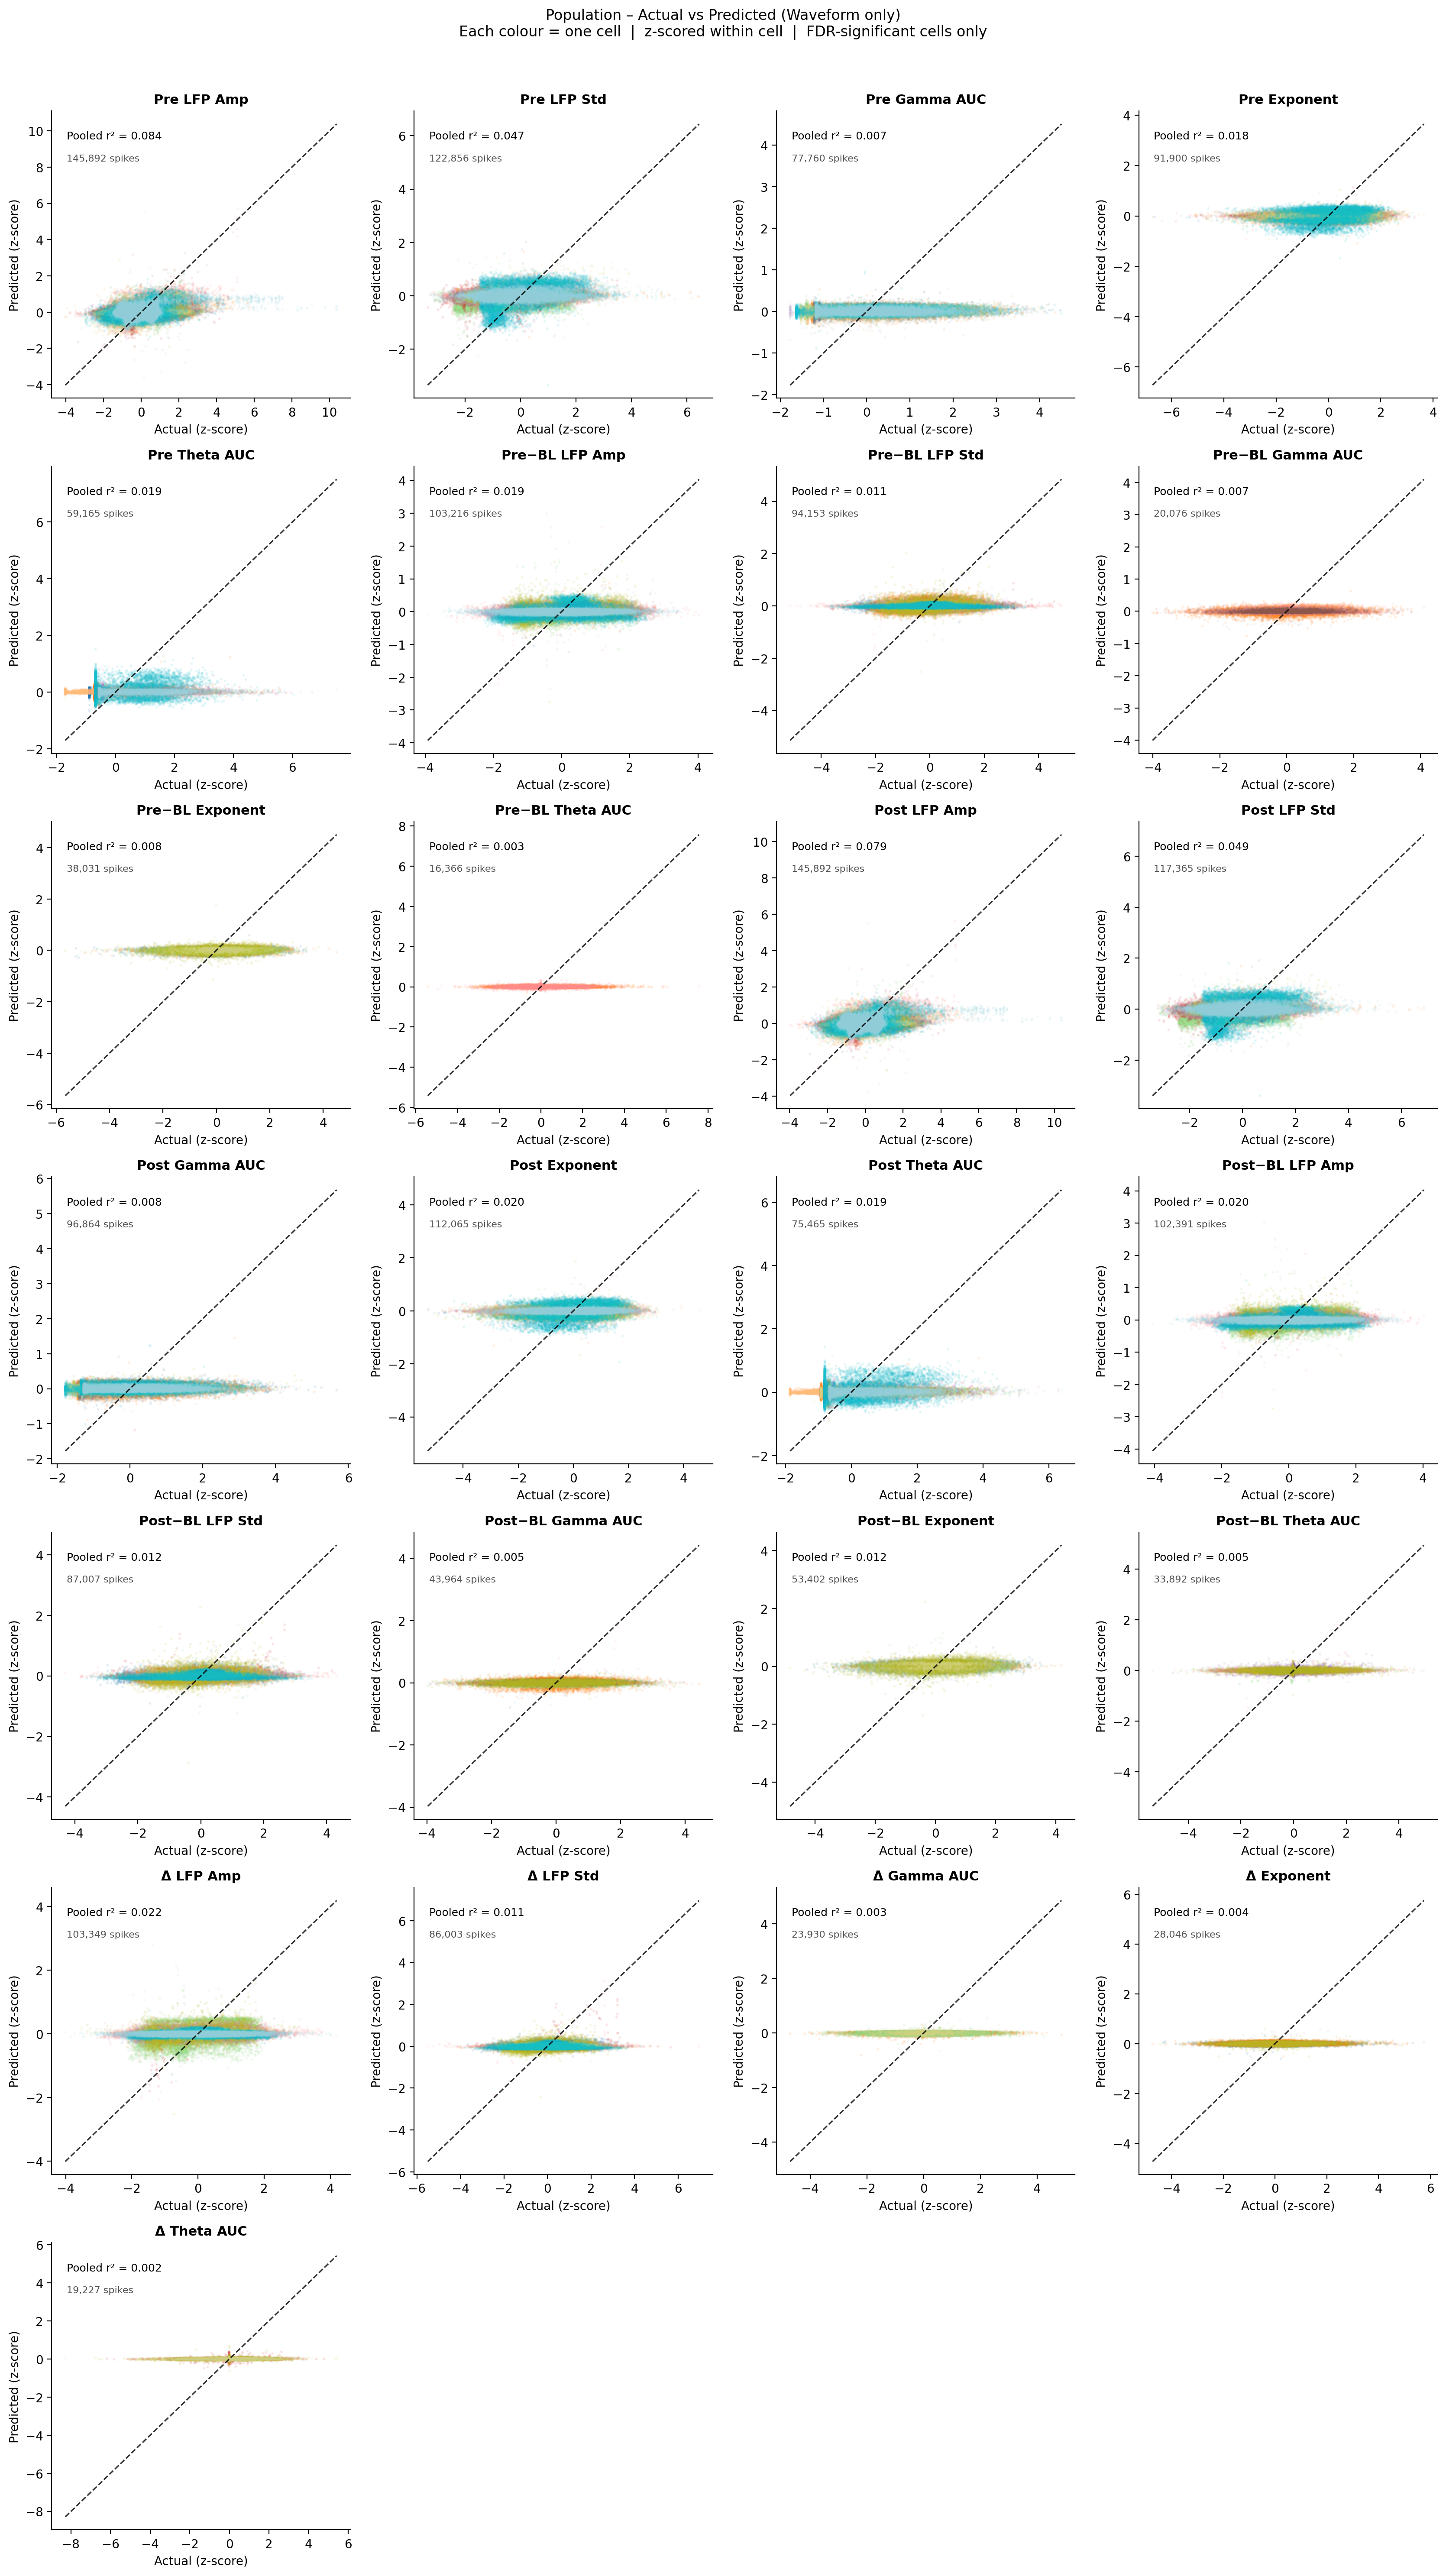

In [7]:
# ── 5. Population scatter (reads from pickles — fast) ────────────────────────
build_population_scatter(all_results, cell_ids, target_names, target_labels)

In [8]:
# ── 6. Save ───────────────────────────────────────────────────────────────────
save_population_results(
    RIDGE_PICKLE_DIR, r2_pop, sig_pop, beta_pop, df_tests,
    mean_r2, frac_sig, mean_beta_mat, sig_beta_mat,
    target_names, target_labels, predictor_sets, cell_ids,
)

Saved: population_ridge_results.pkl
